# Лабораторная работа 2
## Neural ODE для прогнозирования AirPassengers
Исследуем непрерывную динамику скрытого состояния, прогноз на 12 месяцев и
устойчивость к повреждению истории наблюдений. 

## Данные
Классический ряд Box–Jenkins AirPassengers: месячный международный
пассажиропоток в тысячах, январь 1949 — декабрь 1960, 144 наблюдения.
[Документация R](https://stat.ethz.ch/R-manual/R-devel/library/datasets/html/AirPassengers.html),
[CSV](https://raw.githubusercontent.com/vincentarelbundock/Rdatasets/master/csv/datasets/AirPassengers.csv).
[Neural ODE, Chen et al., 2018](https://proceedings.neurips.cc/paper/2018/hash/69386f6bb1dfed68692a24c8686939b9-Abstract.html).


PyTorch: 2.14.0 | CPU | seed: 42
{
  "observations": 144,
  "missing": 0,
  "duplicate_rows": 0,
  "duplicate_times": 0,
  "min": 104.0,
  "max": 622.0,
  "mean": 280.2986145019531,
  "std": 119.54904174804688,
  "sha256": "bdb98adbd418a6de6842a742e0602f363c3b841c26677e7e61a1e055e9509bd8"
}
Подозрительные годовые изменения (не удаляем автоматически): []


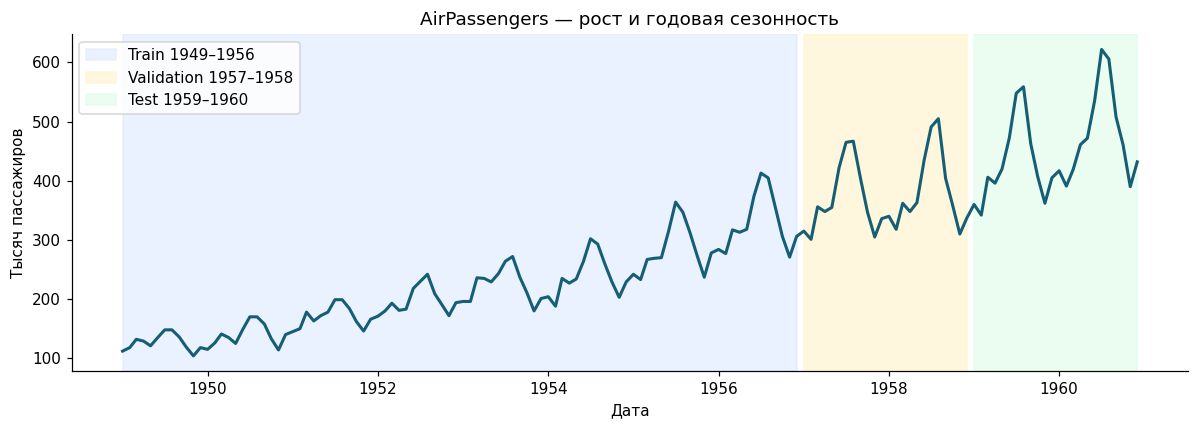

In [ ]:
from pathlib import Path
import copy, hashlib, json, random, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import torch
from torch import nn

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(2)
ROOT = Path.cwd()
FIG = ROOT / 'figures'
FIG.mkdir(exist_ok=True)
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.family': 'DejaVu Sans'})

def savefig(name):
    plt.tight_layout()
    plt.savefig(FIG / f'{name}.png', dpi=170, bbox_inches='tight')
    plt.show()

SOURCE = 'https://raw.githubusercontent.com/vincentarelbundock/Rdatasets/master/csv/datasets/AirPassengers.csv'
path = ROOT / 'data' / 'AirPassengers.csv'
if not path.exists():
    path.parent.mkdir(exist_ok=True)
    pd.read_csv(SOURCE).to_csv(path, index=False)
raw = pd.read_csv(path)
dates = pd.date_range('1949-01-01', periods=len(raw), freq='MS')
values = raw['value'].to_numpy(dtype=np.float32)
assert len(values) == 144 and np.isfinite(values).all() and (values > 0).all()
assert np.allclose(raw['time'], 1949 + np.arange(144)/12)
quality = {'observations': len(raw), 'missing': int(raw.isna().sum().sum()),
           'duplicate_rows': int(raw.duplicated().sum()),
           'duplicate_times': int(raw['time'].duplicated().sum()),
           'min': float(values.min()), 'max': float(values.max()),
           'mean': float(values.mean()), 'std': float(values.std()),
           'sha256': hashlib.sha256(path.read_bytes()).hexdigest()}
print('PyTorch:', torch.__version__, '| CPU | seed:', SEED)
print(json.dumps(quality, indent=2))

yoy = np.log(values[12:]) - np.log(values[:-12])
mad = np.median(np.abs(yoy - np.median(yoy)))
flags = np.abs(yoy - np.median(yoy)) > 4 * 1.4826 * mad
print('Подозрительные годовые изменения (не удаляем автоматически):', dates[12:][flags].strftime('%Y-%m').tolist())
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(dates, values, color='#155e75', lw=2)
for a,b,c,label in [(0,95,'#dbeafe','Train 1949–1956'),(96,119,'#fef3c7','Validation 1957–1958'),(120,143,'#dcfce7','Test 1959–1960')]:
    ax.axvspan(dates[a], dates[b], alpha=.6, color=c, label=label)
ax.set(title='AirPassengers — рост и годовая сезонность', ylabel='Тысяч пассажиров', xlabel='Дата')
ax.legend()
savefig('01_dataset')

## Постановка и защита от утечки будущего
Вход — последние 24 месяца $x\in\mathbb{R}^{24}$ и известная календарная фаза.
Цель — следующие 12 месяцев $y\in\mathbb{R}^{12}$. Прогноз строится целиком
из начального состояния: истинные будущие значения не подаются внутрь решателя.

Train: 1949–1956, validation: 1957–1958, test: 1959–1960. Окно включается
в часть, только если **все 12 целевых месяцев** принадлежат ей. История может
начинаться раньше границы. При сдвиге точки прогноза доступны уже наблюдённые
месяцы; это rolling-origin оценка, а не единственный прогноз на два года.
Перекрывающиеся окна зависимы: число окон не равно числу независимых экспериментов.

$z=(\log y-\mu_{train})/\sigma_{train}$; статистики оцениваются только на train.
Логарифм уменьшает различие амплитуд при росте уровня. Прогноз обратно
преобразуется экспонентой без поправки на смещение; MSE в log-шкале не
эквивалентна MSE в исходных единицах. Повторяющиеся значения пассажиропотока
не являются дубликатами объектов с разными датами. Календарь регулярный;
преимуществ на нерегулярных наблюдениях этот эксперимент не проверяет.

In [2]:
L, H = 24, 12
mu, sigma = float(np.log(values[:96]).mean()), float(np.log(values[:96]).std())
z = (np.log(values) - mu) / sigma

def windows(start, stop):
    origins = np.arange(max(L, start), stop-H+1)
    x = torch.tensor(np.stack([z[o-L:o] for o in origins]), dtype=torch.float32)
    y = torch.tensor(np.stack([z[o:o+H] for o in origins]), dtype=torch.float32)
    # Нулевая точка — последний наблюдённый месяц; t измеряется в годах.
    phase = torch.tensor((origins-1)%12/12, dtype=torch.float32)
    return x, y, phase, origins

parts = {'train': windows(0,96), 'validation': windows(96,120), 'test': windows(120,144)}
for name,(x,y,p,o) in parts.items():
    print(f'{name}: x={tuple(x.shape)}, y={tuple(y.shape)}, первые цели {dates[o[0]]:%Y-%m}, последние {dates[o[-1]+H-1]:%Y-%m}')
assert all((o[:,None]+np.arange(H) < end).all() and (o>=start).all()
           for (_,_,_,o),(start,end) in zip(parts.values(), [(24,96),(96,120),(120,144)]))

def inverse(a):
    if isinstance(a, torch.Tensor): a = a.detach().cpu().numpy()
    return np.exp(a*sigma+mu)

train: x=(61, 24), y=(61, 12), первые цели 1951-01, последние 1956-12
validation: x=(13, 24), y=(13, 12), первые цели 1957-01, последние 1958-12
test: x=(13, 24), y=(13, 12), первые цели 1959-01, последние 1960-12


## Математическая идея и схема
Сеть задаёт производную скрытого состояния, а не сразу 12 выходных значений:

$$h(0)=E_\phi(z_{o-24:o}-z_{o-1})\in\mathbb{R}^{12},\quad
\frac{dh(t)}{dt}=f_\theta(h(t),c(t)),\quad
c(t)=(\sin 2\pi(q+t),\cos 2\pi(q+t)).$$
$$\widehat z_{o+k-1}=z_{o-1}+w^\top[h(k/12)-h(0)],\quad k=1,\dots,12.$$

Схема: **24 наблюдения → log-нормализация → центрирование по последнему
наблюдению → encoder 24→32→12 → ODE 12→32→12 → линейное чтение в 12 моментах → exp**.
Последнее наблюдение служит опорным уровнем. Его вычитание помогает переносить
динамику на другой уровень ряда. Годовая периодичность явно внесена календарём,
а не целиком обнаружена сетью. Она известна до просмотра test.

Решатель RK4 с шагом $\Delta=1/12$ года:
$$k_1=f(t,h),\ k_2=f(t+\Delta/2,h+\Delta k_1/2),\
k_3=f(t+\Delta/2,h+\Delta k_2/2),\ k_4=f(t+\Delta,h+\Delta k_3),$$
$$h_{next}=h+\Delta(k_1+2k_2+2k_3+k_4)/6.$$
Обучение: $\mathcal L=\frac1{NH}\sum(\hat z-z)^2$, Adam, lr=0.003,
weight decay=0.0001, полный batch из train-окон, 500 эпох, clip grad norm=1.

NeuralODE(
  (encoder): Sequential(
    (0): Linear(in_features=24, out_features=32, bias=True)
    (1): Tanh()
    (2): Linear(in_features=32, out_features=12, bias=True)
    (3): Tanh()
  )
  (field): Sequential(
    (0): Linear(in_features=14, out_features=32, bias=True)
    (1): Tanh()
    (2): Linear(in_features=32, out_features=12, bias=True)
  )
  (readout): Linear(in_features=12, out_features=1, bias=False)
)
Параметров: 2084
epoch 1: train MSE=0.32611; validation MSE=0.39139
epoch 100: train MSE=0.05658; validation MSE=0.11117
epoch 200: train MSE=0.04644; validation MSE=0.10723
epoch 300: train MSE=0.03740; validation MSE=0.10226
epoch 400: train MSE=0.02786; validation MSE=0.09716
epoch 500: train MSE=0.02148; validation MSE=0.09400
Лучшая эпоха: 436 | секунд: 8.1


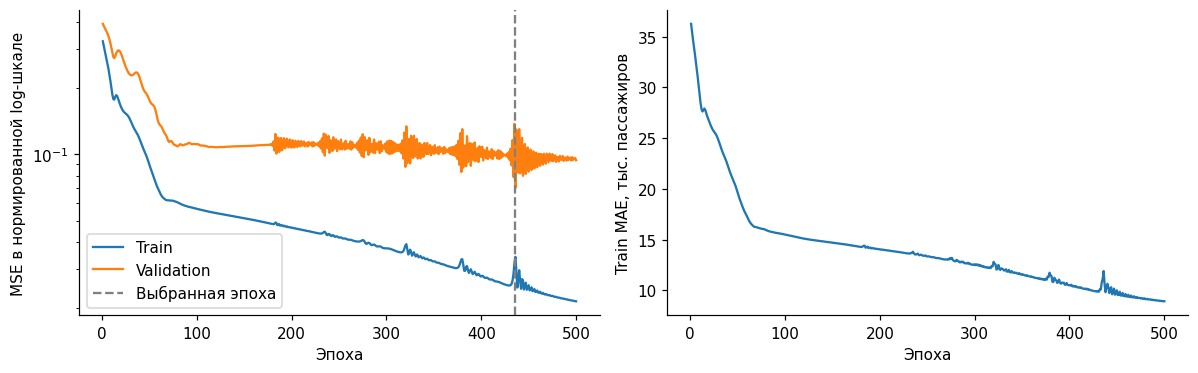

In [3]:
class NeuralODE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(nn.Linear(L,32), nn.Tanh(), nn.Linear(32,12), nn.Tanh())
        self.field = nn.Sequential(nn.Linear(14,32), nn.Tanh(), nn.Linear(32,12))
        self.readout = nn.Linear(12,1,bias=False)

    def f(self, t, h, phase):
        angle = 2*torch.pi*(phase+t)
        calendar = torch.stack([angle.sin(),angle.cos()],dim=1)
        return self.field(torch.cat([h,calendar],dim=1))

    def forward(self,x,phase,substeps=1,trajectory=False,freeze=False):
        h0 = self.encoder(x-x[:,-1:])
        h = h0
        states, outputs = [h0], []
        dt = 1/(12*substeps)
        for k in range(H*substeps):
            t = k*dt
            if not freeze:
                a = self.f(t,h,phase)
                b = self.f(t+dt/2,h+dt*a/2,phase)
                c = self.f(t+dt/2,h+dt*b/2,phase)
                d = self.f(t+dt,h+dt*c,phase)
                h = h+dt*(a+2*b+2*c+d)/6
            if (k+1)%substeps == 0:
                states.append(h)
                outputs.append(x[:,-1]+self.readout(h-h0).squeeze(-1))
        prediction = torch.stack(outputs,dim=1)
        return (prediction,torch.stack(states,dim=1)) if trajectory else prediction

model = NeuralODE()
print(model)
print('Параметров:', sum(p.numel() for p in model.parameters()))
optimizer = torch.optim.Adam(model.parameters(),lr=.003,weight_decay=1e-4)
xt,yt,pt,_ = parts['train']
xv,yv,pv,_ = parts['validation']
history, best, best_state = [], float('inf'), None
started = time.time()
for epoch in range(1,501):
    model.train()
    optimizer.zero_grad()
    loss = (model(xt,pt)-yt).square().mean()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(),1.)
    optimizer.step()
    model.eval()
    with torch.no_grad():
        train_loss = (model(xt,pt)-yt).square().mean().item()
        val_loss = (model(xv,pv)-yv).square().mean().item()
    history.append({'epoch':epoch,'train_mse':train_loss,'validation_mse':val_loss,
                    'train_mae':float(np.abs(inverse(model(xt,pt).detach())-inverse(yt)).mean())})
    if val_loss < best:
        best, best_epoch = val_loss, epoch
        best_state = copy.deepcopy(model.state_dict())
    if epoch == 1 or epoch%100 == 0:
        print(f'epoch {epoch}: train MSE={train_loss:.5f}; validation MSE={val_loss:.5f}')
model.load_state_dict(best_state)
model.eval()
print('Лучшая эпоха:', best_epoch, '| секунд:', round(time.time()-started,1))
history = pd.DataFrame(history)
fig, axes = plt.subplots(1,2,figsize=(11,3.5))
axes[0].plot(history.epoch,history.train_mse,label='Train')
axes[0].plot(history.epoch,history.validation_mse,label='Validation')
axes[0].axvline(best_epoch,color='gray',ls='--',label='Выбранная эпоха')
axes[0].set(yscale='log',xlabel='Эпоха',ylabel='MSE в нормированной log-шкале')
axes[0].legend()
axes[1].plot(history.epoch,history.train_mae)
axes[1].set(xlabel='Эпоха',ylabel='Train MAE, тыс. пассажиров')
savefig('02_learning')

## Базовая оценка и контрольные прогнозы
### Метрики
1) MAE измеряются в тысячах пассажиров
2) RMSE измеряются в тысячах пассажиров 
3) MAPE — в процентах.

Метрики усредняются по всем парам «точка прогноза, горизонт»

Сравниваем Neural ODE с последним значением, сезонным повтором прошлого года
и сезонным повтором с ростом. Последний baseline умножает прошлый год на
отношение средних последних и предпоследних 12 месяцев истории.

     split                  model    MAE   RMSE  MAPE_pct
     train             Neural ODE 11.901 14.884     4.947
     train     Последнее значение 36.581 47.116    14.724
     train        Сезонный повтор 31.096 34.273    12.911
     train Сезонный повтор + рост 15.155 19.097     6.491
validation             Neural ODE 27.095 33.428     7.435
validation     Последнее значение 62.179 79.801    16.118
validation        Сезонный повтор 27.878 32.851     7.346
validation Сезонный повтор + рост 18.922 24.067     5.107
      test             Neural ODE 34.599 44.940     7.785
      test     Последнее значение 77.840 99.226    16.524
      test        Сезонный повтор 51.462 53.366    11.471
      test Сезонный повтор + рост 26.955 29.821     6.182
Типичное окно (медианная MAE): 1960-01-01 00:00:00 MAE 28.596949
Худшее окно: 1959-05-01 00:00:00 MAE 81.63281


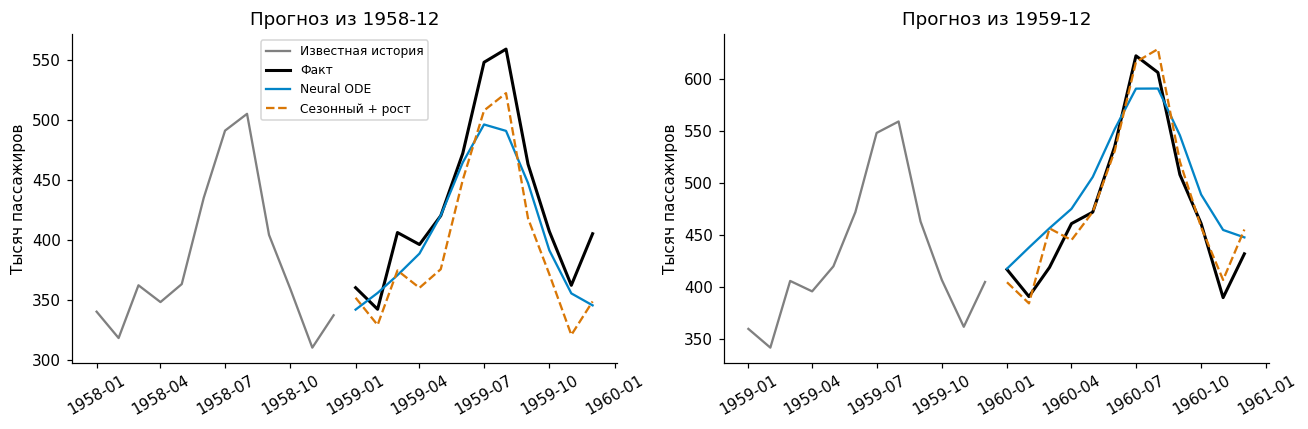

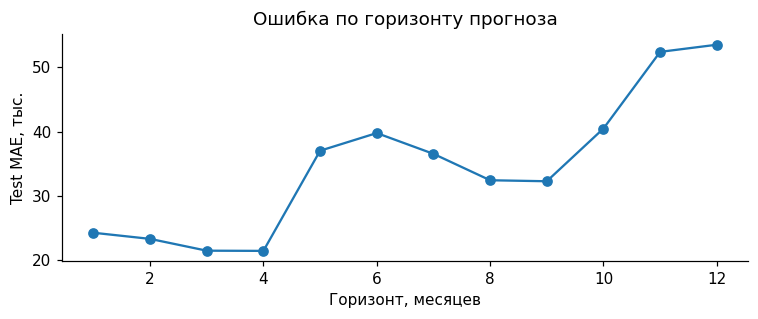

In [4]:
@torch.no_grad()
def predict(x,p,**kwargs):
    return inverse(model(x,p,**kwargs))

def metrics(y,p):
    e = p-y
    return {'MAE':float(np.abs(e).mean()),'RMSE':float(np.sqrt(np.mean(e**2))),
            'MAPE_pct':float(np.mean(np.abs(e)/y)*100)}

def baselines(x):
    a = inverse(x)
    seasonal = a[:,-12:]
    growth = a[:,-12:].mean(axis=1,keepdims=True)/a[:,:12].mean(axis=1,keepdims=True)
    return {'Последнее значение':np.repeat(a[:,-1:],H,axis=1),
            'Сезонный повтор':seasonal,'Сезонный повтор + рост':seasonal*growth}

rows=[]
for split,(x,y,p,o) in parts.items():
    for name,pred in {'Neural ODE':predict(x,p),**baselines(x)}.items():
        rows.append({'split':split,'model':name,**metrics(inverse(y),pred)})
score = pd.DataFrame(rows)
print(score.round(3).to_string(index=False))
x,y,phase,origins = parts['test']
truth, pred = inverse(y), predict(x,phase)
window_mae = np.abs(pred-truth).mean(axis=1)
good = int(np.argmin(np.abs(window_mae-np.median(window_mae))))
bad = int(np.argmax(window_mae))
print('Типичное окно (медианная MAE):', dates[origins[good]], 'MAE', window_mae[good])
print('Худшее окно:', dates[origins[bad]], 'MAE', window_mae[bad])
fig,axes=plt.subplots(1,2,figsize=(12,4))
# Две точки дают неперекрывающиеся прогнозы 1959 и 1960 годов.
for ax,i in zip(axes,[0,len(origins)-1]):
    o=origins[i]
    ax.plot(dates[o-12:o],values[o-12:o],color='gray',label='Известная история')
    ax.plot(dates[o:o+H],truth[i],color='black',lw=2,label='Факт')
    ax.plot(dates[o:o+H],pred[i],color='#0284c7',label='Neural ODE')
    ax.plot(dates[o:o+H],baselines(x)['Сезонный повтор + рост'][i],ls='--',color='#d97706',label='Сезонный + рост')
    ax.set(title=f'Прогноз из {dates[o-1]:%Y-%m}',ylabel='Тысяч пассажиров')
    ax.tick_params(axis='x',rotation=30)
axes[0].legend(fontsize=8)
savefig('03_forecasts')
fig,ax=plt.subplots(figsize=(7,3))
ax.plot(np.arange(1,13),np.abs(pred-truth).mean(axis=0),marker='o')
ax.set(xlabel='Горизонт, месяцев',ylabel='Test MAE, тыс.',title='Ошибка по горизонту прогноза')
savefig('04_horizon')

## Контролируемое нарушение входных данных
Меняем только историю test, сохраняя истинную цель: это повреждение измерений,
а не утверждение, что реальный пассажиропоток изменился без изменения будущего.
Сценарий 1 — случайный шум в log-шкале. Сценарий 2 — white-box FGSM:
$$x_{adv}=x+\epsilon\operatorname{sign}(\nabla_x\mathcal L(x,y)).$$
Истинная цель используется атакующим для стресс-теста; она не передаётся
модели как признак. $\epsilon$ указан в стандартизированной log-шкале.
В исходных единицах изменение ограничено множителями $\exp(\pm\sigma\epsilon)$.
Нет переобучения или выбора параметров по атакованному test.
Проверяем сетку 0, 0.05, 0.10, 0.20; для случайного шума — 10 повторов.
Искажения строятся отдельно для каждого окна: это отдельные запросы прогноза,
а не единая согласованная подмена всего ряда. У Gaussian ε — стандартное
отклонение, у FGSM — максимальная амплитуда; ограничения различаются.

          scenario  epsilon     MAE    RMSE  MAPE_pct  MAE_std
              FGSM     0.00  34.599  44.940     7.785      NaN
Gaussian mean (10)     0.00  34.599  44.940     7.785    0.000
              FGSM     0.05  59.432  73.371    13.375      NaN
Gaussian mean (10)     0.05  34.634  44.726     7.796    1.743
              FGSM     0.10  85.423 102.029    19.129      NaN
Gaussian mean (10)     0.10  36.121  46.472     8.111    3.190
              FGSM     0.20 128.929 151.117    28.715      NaN
Gaussian mean (10)     0.20  42.427  54.588     9.448    5.052
FGSM eps=0.1: множители измерений от 0.9672 до 1.0339


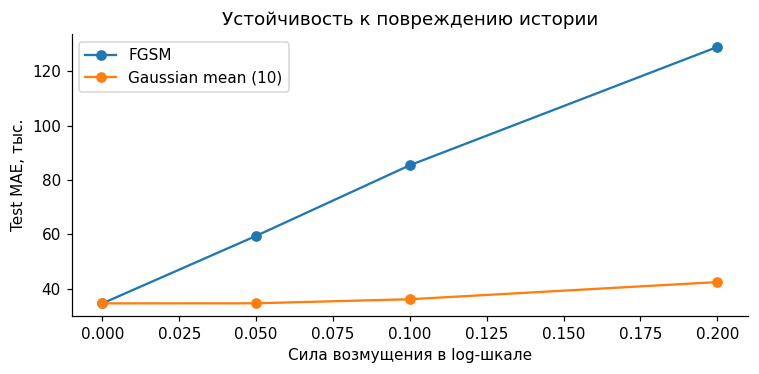

In [5]:
attack_x = x.clone().requires_grad_(True)
attack_loss=(model(attack_x,phase)-y).square().mean()
grad=torch.autograd.grad(attack_loss,attack_x)[0]
robust=[]
for eps in [0.,.05,.10,.20]:
    adv=x+eps*grad.sign()
    robust.append({'scenario':'FGSM','epsilon':eps,**metrics(truth,predict(adv,phase))})
    noise_scores=[]
    for seed in range(10):
        gen=torch.Generator().manual_seed(1000+seed)
        noisy=x+eps*torch.randn(x.shape,generator=gen)
        noise_scores.append(metrics(truth,predict(noisy,phase)))
    robust.append({'scenario':'Gaussian mean (10)','epsilon':eps,
                   **{k:float(np.mean([a[k] for a in noise_scores])) for k in noise_scores[0]},
                   'MAE_std':float(np.std([a['MAE'] for a in noise_scores]))})
robust=pd.DataFrame(robust)
print(robust.round(3).to_string(index=False))
EPS=.10
x_adv=x+EPS*grad.sign()
pred_adv=predict(x_adv,phase)
print(f'FGSM eps={EPS}: множители измерений от {np.exp(-sigma*EPS):.4f} до {np.exp(sigma*EPS):.4f}')
fig,ax=plt.subplots(figsize=(7,3.5))
for scenario,g in robust.groupby('scenario'):
    ax.plot(g.epsilon,g.MAE,marker='o',label=scenario)
ax.set(xlabel='Сила возмущения в log-шкале',ylabel='Test MAE, тыс.',title='Устойчивость к повреждению истории')
ax.legend()
savefig('05_robustness')

## Интерпретация 1 — траектории скрытого состояния
PCA обучается **только на траекториях train**. На общей проекции сравниваются
типичное окно, худшее окно и атакованная версия типичного. Дополнительно
измеряется расстояние между чистой и атакованной траекториями в полном
12-мерном пространстве. PCA показывает лишь часть геометрии; близость на
рисунке не доказывает идентичность состояний или причинный механизм.

Объяснённая дисперсия PCA: [0.42536926 0.2989861 ] сумма 0.72435534


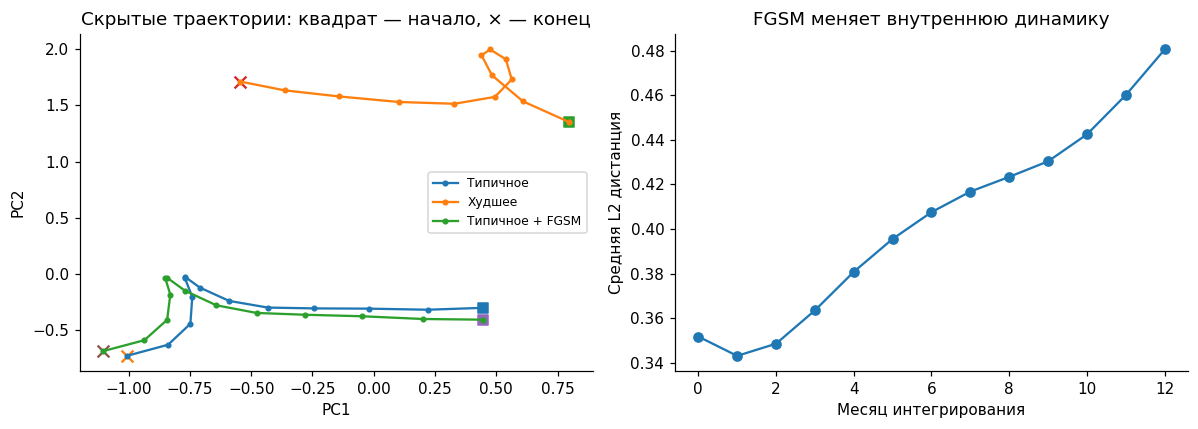

In [6]:
with torch.no_grad():
    _,train_h=model(xt,pt,trajectory=True)
    _,clean_h=model(x,phase,trajectory=True)
    _,adv_h=model(x_adv,phase,trajectory=True)
pca=PCA(n_components=2).fit(train_h.numpy().reshape(-1,12))
print('Объяснённая дисперсия PCA:',pca.explained_variance_ratio_, 'сумма',pca.explained_variance_ratio_.sum())
fig,axes=plt.subplots(1,2,figsize=(11,4))
for label,h in [('Типичное',clean_h[good]),('Худшее',clean_h[bad]),('Типичное + FGSM',adv_h[good])]:
    coords=pca.transform(h.numpy())
    axes[0].plot(coords[:,0],coords[:,1],marker='.',label=label)
    axes[0].scatter(*coords[0],marker='s',s=50)
    axes[0].scatter(*coords[-1],marker='x',s=60)
axes[0].set(xlabel='PC1',ylabel='PC2',title='Скрытые траектории: квадрат — начало, × — конец')
axes[0].legend(fontsize=8)
hidden_distance=torch.linalg.vector_norm(adv_h-clean_h,dim=2).numpy()
axes[1].plot(np.arange(13),hidden_distance.mean(axis=0),marker='o')
axes[1].set(xlabel='Месяц интегрирования',ylabel='Средняя L2 дистанция',title='FGSM меняет внутреннюю динамику')
savefig('06_hidden')

## Интерпретация 2 — чувствительность прогноза к истории
Для каждого из трёх объектов вычисляем
$S_j=\frac1{12}\sum_k|\partial\hat z_k/\partial x_j|$.
Это локальная чувствительность к небольшому изменению конкретного месяца,
а не причинная важность. Используем одинаковый масштаб оси для чистого
и атакованного входа. Для регрессии «типичное» означает медианную ошибку;
модель не выдаёт вероятностную уверенность.

Наиболее чувствительные лаги типичного окна: [0, -1, -12, -13, -17]


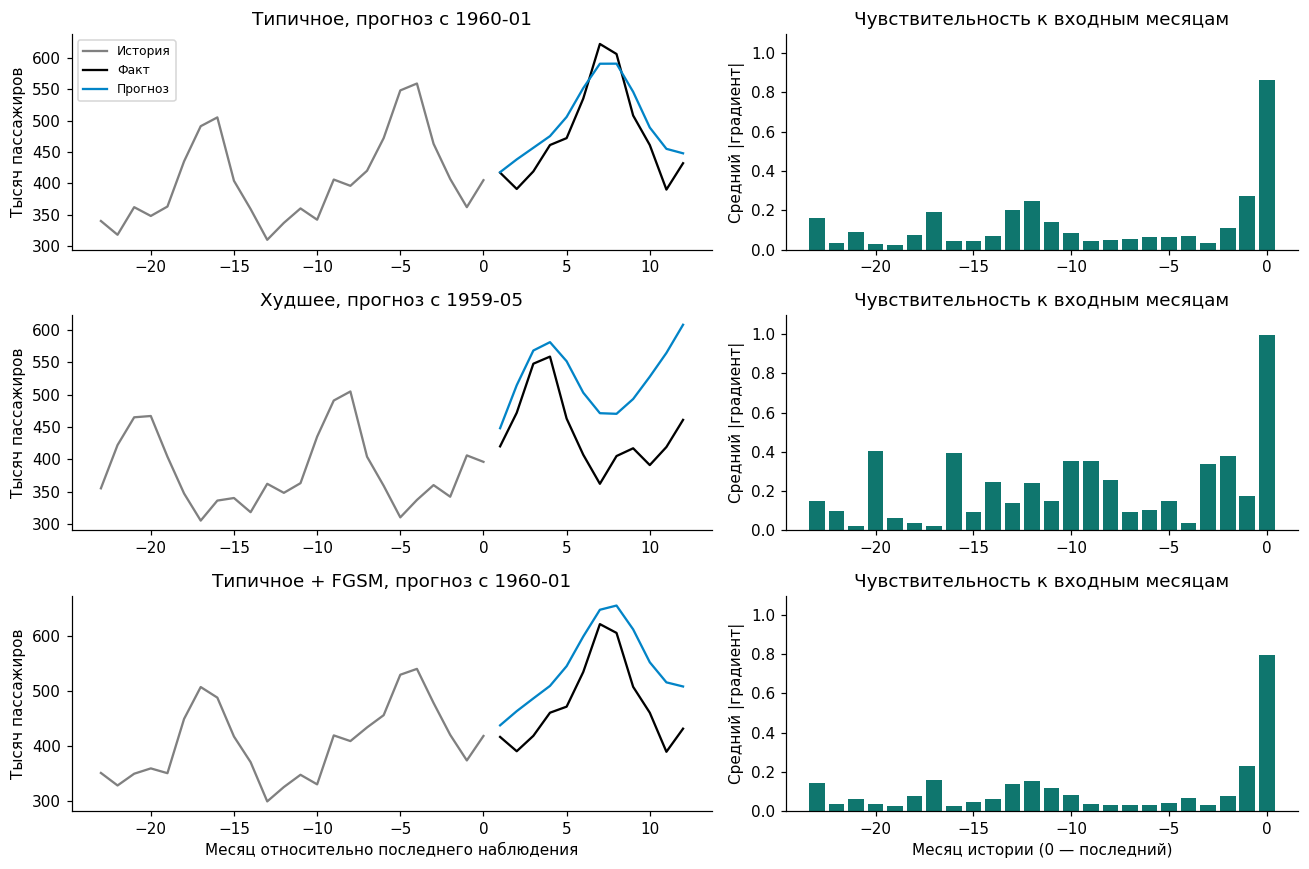

In [7]:
cases=[('Типичное',x[good:good+1],phase[good:good+1],good),
       ('Худшее',x[bad:bad+1],phase[bad:bad+1],bad),
       ('Типичное + FGSM',x_adv[good:good+1],phase[good:good+1],good)]
sal=[]
for label,xx,pp,i in cases:
    xx=xx.detach().requires_grad_(True)
    jac=torch.autograd.functional.jacobian(lambda a:model(a,pp),xx)
    sal.append(jac[0,:,0,:].abs().mean(dim=0).numpy())
sal=np.stack(sal)
fig,axes=plt.subplots(3,2,figsize=(12,8),gridspec_kw={'width_ratios':[1.25,1]})
for row,(label,xx,pp,i) in enumerate(cases):
    o=origins[i]
    axes[row,0].plot(np.arange(-23,1),inverse(xx)[0],color='gray',label='История')
    axes[row,0].plot(np.arange(1,13),truth[i],color='black',label='Факт')
    axes[row,0].plot(np.arange(1,13),predict(xx,pp)[0],color='#0284c7',label='Прогноз')
    axes[row,0].set(title=f'{label}, прогноз с {dates[o]:%Y-%m}',ylabel='Тысяч пассажиров')
    axes[row,1].bar(np.arange(-23,1),sal[row],color='#0f766e')
    axes[row,1].set(ylim=(0,float(sal.max()*1.1)),ylabel='Средний |градиент|',title='Чувствительность к входным месяцам')
axes[0,0].legend(fontsize=8)
axes[-1,0].set_xlabel('Месяц относительно последнего наблюдения')
axes[-1,1].set_xlabel('Месяц истории (0 — последний)')
savefig('07_interpretation')
print('Наиболее чувствительные лаги типичного окна:', (np.argsort(sal[0])[-5:][::-1]-23).tolist())

## Проверка численного решения и роли динамики
Уменьшаем шаг RK4 вдвое при неизменных весах. Малое изменение прогноза означает
согласованность двух дискретизаций на проверенных входах; это не доказательство
абсолютной точности. Затем замораживаем $h(t)=h(0)$: модель вырождается в
прогноз последним значением. Это абляция обученной системы, не сравнение с
отдельно обученной моделью без ODE и не доказательство превосходства архитектуры.

In [8]:
finer=predict(x,phase,substeps=2)
frozen=predict(x,phase,freeze=True)
solver_delta=float(np.abs(finer-pred).max())
print('Максимальное изменение при половинном шаге RK4, тыс.:',solver_delta)
print('Замороженная динамика:',metrics(truth,frozen))
assert np.isfinite(pred).all() and np.isfinite(pred_adv).all()
assert np.allclose(frozen,baselines(x)['Последнее значение'],rtol=1e-5)
summary={'dataset':quality,'seed':SEED,'best_epoch':best_epoch,'parameters':sum(p.numel() for p in model.parameters()),
         'metrics':rows,'robustness':robust.fillna(0).to_dict('records'),
         'sigma_log_train':sigma,'solver_max_delta':solver_delta,
         'pca_variance':pca.explained_variance_ratio_.tolist(),
         'typical_origin':str(dates[origins[good]].date()),'worst_origin':str(dates[origins[bad]].date()),
         'typical_mae':float(window_mae[good]),'worst_mae':float(window_mae[bad]),
         'sensitive_lags':(np.argsort(sal[0])[-5:][::-1]-23).tolist(),
         'hidden_distance_start':float(hidden_distance[:,0].mean()),'hidden_distance_end':float(hidden_distance[:,-1].mean())}
(ROOT/'results.json').write_text(json.dumps(summary,ensure_ascii=False,indent=2))
score.to_csv(ROOT/'metrics.csv',index=False)
history.to_csv(ROOT/'history.csv',index=False)
robust.to_csv(ROOT/'robustness.csv',index=False)
torch.save({'state_dict':model.state_dict(),'mu':mu,'sigma':sigma,'seed':SEED},ROOT/'neural_ode_airpassengers.pt')
clean_mae=metrics(truth,pred)['MAE']
adv_mae=metrics(truth,pred_adv)['MAE']
base_mae=metrics(truth,baselines(x)['Сезонный повтор + рост'])['MAE']
conclusion=f'''Neural ODE: test MAE {clean_mae:.2f} тыс.; сезонный прогноз с ростом: {base_mae:.2f} тыс.
FGSM ε=0.10: MAE {adv_mae:.2f} тыс. ({adv_mae/clean_mae:.2f}× от чистого test).
Худшее окно: {dates[origins[bad]]:%Y-%m}, MAE {window_mae[bad]:.2f} тыс.
Изменение прогноза при половинном шаге RK4: не более {solver_delta:.4f} тыс.
Наиболее чувствительные лаги типичного окна: {summary['sensitive_lags']}.
Расстояние чистого и атакованного скрытых состояний: {summary['hidden_distance_start']:.3f} → {summary['hidden_distance_end']:.3f}.'''
print(conclusion)
(ROOT/'conclusion.txt').write_text(conclusion)

Максимальное изменение при половинном шаге RK4, тыс.: 0.02130126953125
Замороженная динамика: {'MAE': 77.8397445678711, 'RMSE': 99.22621154785156, 'MAPE_pct': 16.524171829223633}
Neural ODE: test MAE 34.60 тыс.; сезонный прогноз с ростом: 26.96 тыс.
FGSM ε=0.10: MAE 85.42 тыс. (2.47× от чистого test).
Худшее окно: 1959-05, MAE 81.63 тыс.
Изменение прогноза при половинном шаге RK4: не более 0.0213 тыс.
Наиболее чувствительные лаги типичного окна: [0, -1, -12, -13, -17].
Расстояние чистого и атакованного скрытых состояний: 0.352 → 0.480.


## Выводы и ограничения
Обучена Neural ODE для 12-месячного прогнозирования. Её центральная идея —
обучаемое векторное поле и интегрирование скрытой динамики по времени.


В выполненном опыте test MAE Neural ODE = 34,60 тыс., сезонного baseline
с ростом = 26,96 тыс. Neural ODE уступает ему, хотя лучше подгоняет train.
Это показывает ограничение сложной модели на маленьком ряду. При FGSM
ε=0,10 MAE выросла до 85,42 тыс. (2,47×), тогда как случайный шум дал
36,12 тыс. в среднем. Это разные по ограничениям типы возмущения.

По графикам прогноза можно проверить передачу роста и сезонных максимумов;
различие реального ряда и гладкой траектории отражается в ошибках по месяцам.
Причины нельзя строго установить по одному ряду: возможны сглаживание пиков,
неточный перенос темпа роста и переобучение на зависимых окнах.

Для типичного окна выделяются лаги 0, −1, −12, −13, −17: это согласуется
с опорой на недавний уровень и годовую историю. L2 дистанция чистых
и атакованных состояний возрастает в среднем с 0,352 до 0,480.
PCA и полные L2 расстояния показывают изменение скрытых представлений при
атаке; градиенты связывают прогноз с конкретными месяцами истории. Опорный
уровень последнего наблюдения встроен в модель, поэтому его влияние отчасти
задано конструкцией. Фаза календаря также задана явно. Эти опыты не доказывают,
что координаты скрытого состояния имеют физический смысл.

FGSM — искусственный white-box стресс-тест с известной целью; он не оценивает
вероятность реальной атаки. Gaussian-повторы оценивают изменчивость шума,
но не неопределённость обучения. Один seed, короткий ряд и зависимые окна
ограничивают выводы; доверительные интервалы по независимым объектам неприменимы.
Меры улучшения: больше рядов и временных разбиений, несколько seed,
обучение с шумом/пропусками истории, контроль измерений и сравнение с ETS/SARIMA.
Эффект этих мер здесь не измерен. Для нерегулярных наблюдений нужно отдельно
менять encoder: текущий использует регулярные 24 месяца.